In [84]:
from dotenv import load_dotenv
load_dotenv()

import requests, os

In [29]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal

## Libs for Agents
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

In [30]:
## Allowed categories = coding, google_search, weather
class FlowState(BaseModel):
    question: str = Field(description="user Asked Question")
    category: Literal['coding', 'google_search', 'weather'] = Field(default='google_search')
    answer: str = Field(default="") 

In [31]:
class QuestionCategory(BaseModel):
    category: Literal['coding', 'google_search', 'weather'] = Field(description="Question Cateogory")

In [32]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [91]:
# build google_search agent & weather agent
search = GoogleSerperAPIWrapper()
tools = [search.run]

google_search_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a search agent & can search for any queries on google. give responses in brief."
)

## Weather Agent
@tool
def get_weather(city:str):
    """It provides real time weather details for any city"""

    WEATHER_API_KEY = os.getenv("WEATHER_API_KEY")
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={WEATHER_API_KEY}&units=metric"

    try:
        response = requests.get(url)
        data = response.json()

        if response.status_code != 200:
            return f"Error: {data.get('message')}"
        
        temp = data["main"]["temp"]
        humidity = data["main"]["humidity"]
        weather = data["weather"][0]["main"]

        return f"{city}: {temp}°C, {weather} , Humidity: {humidity}%"

    except Exception as e:
        return f"Failed to fetch weather: {str(e)}"
        
weather_agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="""You are a weather assistant. Always use the get_weather tool for real-time data."""
)


In [52]:
def check_question_category(state:FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of my question, question is {state.question}, If you're not sure then give 'google_search as a category")
    state.category = res.category
    return state

In [53]:
flow = FlowState(question="What is Python? ?")
check_question_category(flow)

FlowState(question='What is Python? ?', category='coding', answer='')

In [54]:
def route(state:FlowState) -> Literal['coding', 'google_search', 'weather']:
    return state.category

In [115]:
def coding_node(state:FlowState) -> FlowState:
    print("Coding Node")
    res = llm.invoke(f"You are a coding expert. give responses in brief: {state.question}")
    state.answer = res.content
    return state
    

In [56]:
def google_search_node(state:FlowState) -> FlowState:
    res = google_search_agent.invoke({"messages":[{"role":"user", "content":state.question}]})
    state.answer = res["messages"][-1].content
    return state

In [57]:
def weather_node(state:FlowState) -> FlowState:
    res = weather_agent.invoke({"messages":[{"role":"user", "content":state.question}]})
    state.answer = res["messages"][-1].content
    return state

In [116]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("google_search", google_search_node)
graph.add_node("weather", weather_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()

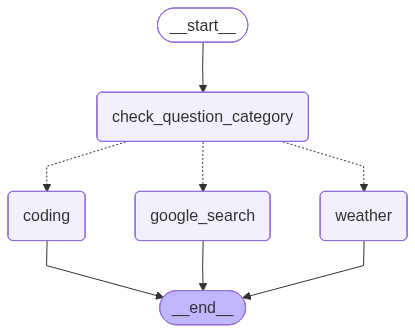

In [43]:
graph

In [ ]:
graph.invoke({"question":"what is Artemis Mission?"})

{'question': 'what is Artemis Mission?',
 'category': 'google_search',
 'answer': 'The Artemis mission is a NASA mission aimed at returning humans to the lunar surface by 2025. The mission plans to send the first woman and the first person of color to the Moon, and establish a sustainable presence on the lunar surface. The mission will also include sending astronauts to the lunar south pole, where they will search for water ice and other resources that can be used to support future human missions to Mars and beyond.'}

In [96]:
graph.invoke({"question":"what is the current weather in Prayagraj?"})

{'question': 'what is the current weather in Prayagraj?',
 'category': 'weather',
 'answer': 'The current weather in Prayagraj (also known as Allahabad) is 29.72°C with clear skies and a humidity of 15%.'}

In [117]:
graph.invoke({"question":"what is Square Root Decomposition?"})

Coding Node


{'question': 'what is Square Root Decomposition?',
 'category': 'coding',
 'answer': 'Square Root Decomposition is a technique used to optimize algorithms by dividing a large array into smaller sub-arrays of size √n, reducing time complexity from O(n) to O(√n) in certain problems.'}